# Hierarchical DDM regressions

 This tutorial walks you through fitting hierarchical Drift Diffusion Models (DDMs) with HSSM. If you're new to HSSM, please click this [link](https://lnccbrown.github.io/HSSM/getting_started/getting_started/). For background on hierarchical modeling in HSSM, please click this [link](https://lnccbrown.github.io/HSSM/getting_started/hierarchical_modeling/).
We'll move through four progressively more complex scenarios, each demonstrating a different real-world experimental design and the kind of regression formula you'd use to capture it.


Here are all 4 scenarios:

| Variant | Scenario | v formula |
|--|--|--|
| **A** | A *within-subject* experiment where each trial varies in difficulty. | `v ~ 0 + difficulty + (1 + difficulty \| participant_id)` |
| **B** | Same as A, but participants also differ in age (a *between-subject* factor). Age affects drift rate on top of the *within-subject* difficulty effect. | `v ~ 0 + age + difficulty + (1 + difficulty \| participant_id)` |
| **C** | Same as B, but with an *interaction*: the effect of difficulty on drift rate varies with age. | `v ~ 0 + age + difficulty + age:difficulty + (1 + difficulty \| participant_id)` |
| **D** | Same v regression as A, but now every DDM parameter (a, z, t) gets its own per-participant random intercept — this is "fully hierarchical" case. | (v same as A; full hierarchy on a, z, t) |

In Variants A–C the other parameters (a, z, t) are estimated globally (`param ~ 1`) — this keeps the focus on the v regression and makes sampling fast. Variant D shows what happens when we add hierarchy to every parameter, demonstrating the fully hierarchical case.

### Note

Each variant follows the same pattern: **simulate synthetic data with known parameter values, fit the model, then check whether we recovered the true parameters.** This is *parameter recovery* — the standard sanity check before applying a model to real data.

If you already have your own data to estimate, you can **skip the simulation steps and go straight to the model fitting**. But running the simulation to recovery loop on synthetic data first is always a good idea — it confirms your modelling pipeline can actually recover the parameters it's supposed to estimate before you trust its inferences on real data.

### Layout of each variant

1. Pick ground-truth coefficients and simulate synthetic data with the **do-operator**
2. Fit a HSSM model to that data
3. Model graph and posterior summary
4. Check parameter recovery and posterior predictive fit

In [1]:
import tempfile
import warnings
from pathlib import Path


def _format_warning(message, category, filename, lineno, line=None):
    """Render saved warnings without machine-local file paths."""
    del filename, lineno, line
    return f"{category.__name__}: {message}\n"


warnings.formatwarning = _format_warning

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

import hssm

rng = np.random.default_rng(0)

# simulated-data checkpoints go to a temp dir, not the docs tree
SIM_DIR = Path(tempfile.mkdtemp(prefix="hssm_hierarchical_sim_"))
# JAX emits os.fork warnings under multiprocess sampling; harmless here
warnings.filterwarnings("ignore", message=".*os.fork.*")

sample_kwargs = dict(
    draws=1000,
    tune=500,
    chains=4,
    target_accept=0.9,
    omit_offsets=True,
    idata_kwargs={"log_likelihood": False},
)

## Covariates

We'll have **10 participants** doing **250 trials each**, giving us 2500 trials total.

Two covariates are tracked throughout:

- `difficulty` — varies trial-by-trial (*within-subject*)
- `age` — one value per participant (*between-subject*)

`difficulty` is simulated on a 0-10 scale, and `age` is represented as participant age in years. The `rt` and `response` columns start as placeholders and get filled in after simulation.

In this synthetic setup, larger `difficulty` values correspond to trials with stronger or clearer evidence, so drift rate increases as `difficulty` increases. `age` is represented as participant age in years; older participants are assumed to have higher drift rates.


In [2]:
n_participants = 10
n_trials = 250

pid = np.repeat(np.arange(n_participants), n_trials)

# Trial-level difficulty on a readable 0-10 scale.
difficulty = rng.uniform(0, 10, size=n_participants * n_trials)

# Participant-level age in years.
age_by_p = rng.uniform(20, 75, size=n_participants)
age = age_by_p[pid]

covariates = pd.DataFrame(
    {
        "participant_id": pid,
        "difficulty": difficulty,
        "age": age,
        "rt": np.nan,
        "response": np.nan,
    }
)
covariates.head()

,participant_id,difficulty,age,rt,response
0,0,6.369617,60.357299,NaN,NaN
1,0,2.697867,60.357299,NaN,NaN
2,0,0.409735,60.357299,NaN,NaN
3,0,0.165276,60.357299,NaN,NaN
4,0,8.132702,60.357299,NaN,NaN


## Simulating synthetic data with the do-operator


### What is the do-operator doing?

It intervenes on the model's parameters by fixing them to specific values, then sample the likelihood to generate fresh `rt` / `response` data. The result is synthetic data that we know was generated from that exact parameter setting.

In code, this looks like `model.sample_do(params={...})`. We pass it a dictionary of parameter values and it returns a fresh dataset.

For a deeper walkthrough of `sample_do`, see the [HSSM do-operator tutorial](https://lnccbrown.github.io/HSSM/tutorials/do_operator/).


## Variant A: within-subject 

Each trial varies in `difficulty`. Each participant has their own baseline drift rate and their own sensitivity to difficulty.

Drift rate `v` depends on `difficulty`, and each participant gets their own intercept and slope.

The other parameters (`a`, `z`, `t`) are kept as global scalars - no per-participant variation, no regression. 

### Step 1: Simulate the data

We pick ground-truth values for the regression coefficients (e.g. `beta_v_difficulty = 0.08`), determine the per-participant random effects, and pass everything to the model via the do-operator. Outcomes are synthetic `rt`/`response` data that we know was generated from this exact parameter setting.

Because `a`, `z`, `t` are global scalars in this variant, we simulate them as scalars too.

In [3]:
# true coefficients for variant A
beta_v_difficulty = 0.08
sigma_v_int, sigma_v_slope = 0.3, 0.2

v_int_p = rng.normal(0, sigma_v_int, n_participants)
v_slope_p = rng.normal(0, sigma_v_slope, n_participants)
a_true, z_true, t_true = 1.2, 0.5, 0.25

# Noncentered offsets for the random effects
v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_A_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": "v ~ 0 + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


<environment>/src/hssm/base.py:390: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()


To see how HSSM relates to PyMC, please click this [link](https://lnccbrown.github.io/HSSM/archive/pymc_to_hssm/).

In [4]:
# Use do-operator
synth_idata_A, synth_model_A = model_A_gen.sample_do(
    params={
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_mu": 0.0,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "v_difficulty|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    var_names=["rt,response"],
    return_model=True,
)

<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [rt,response]


The graph below shows the response-generating part of the synthetic model after the do-operator has fixed the parameters used for simulation. For details on how PyMC renders model graphs, see the [`pm.model_to_graphviz` documentation](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model_graph.model_to_graphviz.html).


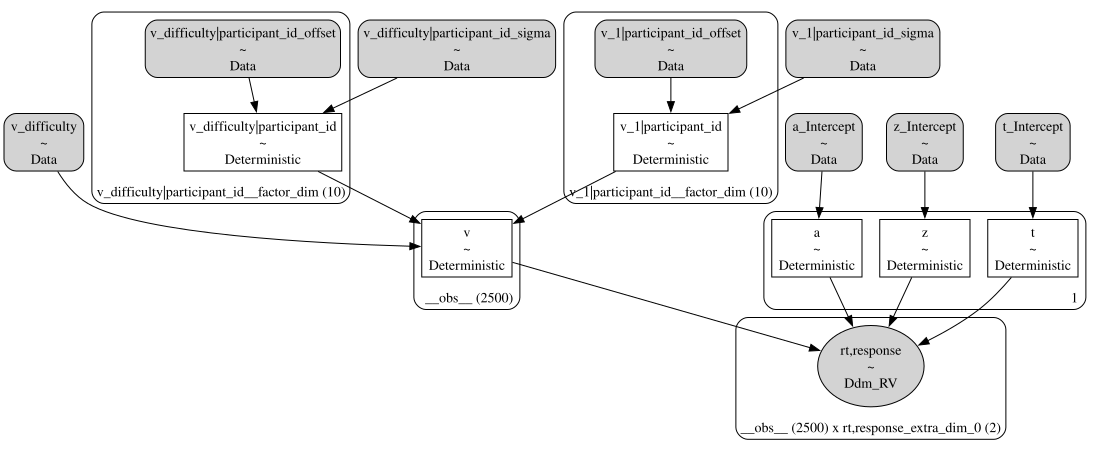

In [5]:
pm.model_to_graphviz(synth_model_A, var_names=["rt,response"])

The below cell converts simulated prior predictive outputs from the HSSM model into a DataFrame and extracts the generated reaction times (rt) and responses. It then merges these simulated outcomes with the original covariates to create a complete synthetic dataset and saves it as a CSV file.

In [6]:
synth_df_A = hssm.utils.predictive_dt_to_dataframe(
    synth_idata_A, predictive_group="prior_predictive"
)

data_A = covariates.copy()
data_A["rt"] = synth_df_A["rt"].values
data_A["response"] = synth_df_A["response"].values

data_A.to_csv(SIM_DIR / "sim_variant_A.csv", index=False)
data_A.head()

,participant_id,difficulty,age,rt,response
0,0,6.369617,60.357299,1.596770,-1.0
1,0,2.697867,60.357299,1.303856,-1.0
2,0,0.409735,60.357299,1.504292,-1.0
3,0,0.165276,60.357299,0.595264,-1.0
4,0,8.132702,60.357299,0.848815,-1.0


### Step 2: Fit a fresh HSSM model

Now we pretend we don't know the true parameters and try to recover them from the data. We reload the saved CSV, build a new HSSM model with the same regression structure, and explore the posterior.

In [7]:
data_A = pd.read_csv(SIM_DIR / "sim_variant_A.csv")

# Bin difficulty into 3 levels (low/med/high) for PPC plots
data_A["difficulty_level"] = pd.qcut(
    data_A["difficulty"], q=3, labels=["low", "med", "high"]
)

model_A = hssm.HSSM(
    data=data_A,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": "v ~ 0 + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


#### Sanity check before sampling

`print(model)` shows every parameter's formula in text. The PyMC/Graphviz call below draws the response-generating subgraph, which is useful for checking that the regression structure and participant-level hierarchy feed into `rt,response` as expected. For details on PyMC model graphs, see the [`pm.model_to_graphviz` documentation](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model_graph.model_to_graphviz.html).

For more example graphs across HSSM models, see the [Scientific Workflow tutorial](https://lnccbrown.github.io/HSSM/tutorials/scientific_workflow_hssm/).


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2500

Parameters:

v:
    Formula: v ~ 0 + difficulty + (1 + difficulty | participant_id)
    Priors:
        v_difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: Normal(mu: 2.0, sigma: 3.0), sigma: HalfNormal(sigma: 2.0))
        v_difficulty|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Intercept ~ Gamma(mu: 0.2, sigma: 0.2)
    Link: identity
    Explicit bounds: (0.0, inf)


Lapse probability: 0.05
Lapse distribution: Uniform(lower: 0.0, upper: 

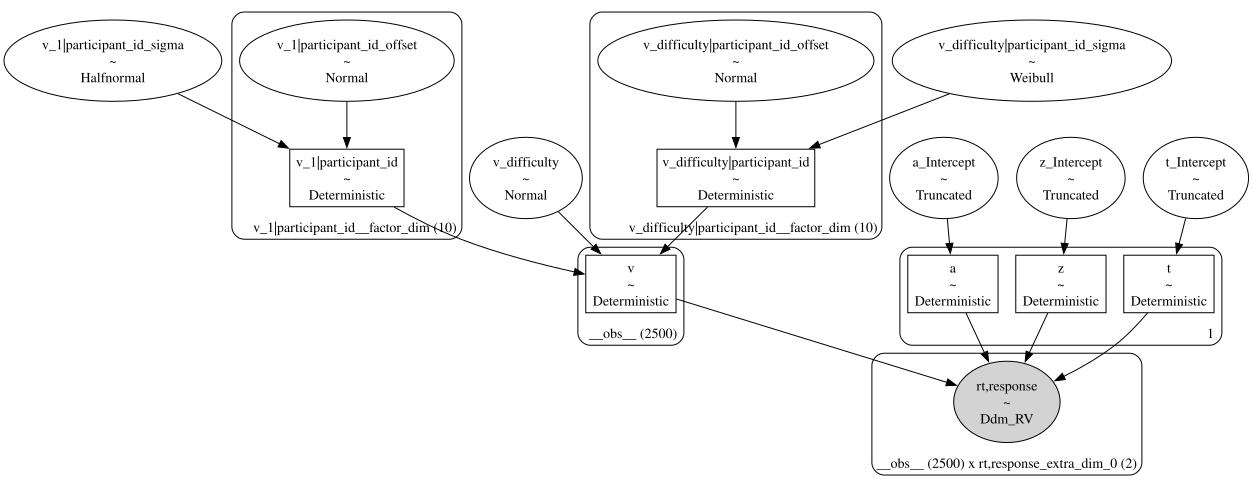

In [8]:
print(model_A)
pm.model_to_graphviz(model_A.pymc_model, var_names=["rt,response"])

In [9]:
idata_A = model_A.sample(**sample_kwargs)

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v_difficulty, v_1|participant_id_mu, v_1|participant_id_sigma, v_1|participant_id_offset, v_difficulty|participant_id_sigma, v_difficulty|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 166 seconds.


### Step 3: Inspect what got estimated
 
 First look at all estimated variables (no `var_names` filter) — this is how you discover the participant-wise parameters needed for recovery checks.

In [10]:
az.summary(idata_A)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_1|participant_id_sigma,0.295,0.098,0.17,0.47,1034,1671,1.00,0.0028,0.0039
v_difficulty|participant_id[0],-0.219,0.07,-0.33,-0.11,785,1226,1.00,0.0025,0.0019
v_difficulty|participant_id[1],0.282,0.072,0.17,0.39,859,1309,1.00,0.0024,0.0019
v_difficulty|participant_id[2],0.12,0.07,0.012,0.23,775,1227,1.00,0.0025,0.0019
v_difficulty|participant_id[3],-0.145,0.069,-0.26,-0.036,766,1140,1.00,0.0025,0.0019
v_difficulty|participant_id[4],0.209,0.07,0.099,0.32,803,1248,1.00,0.0025,0.0019
v_difficulty|participant_id[5],0.105,0.068,-0.0021,0.21,775,1102,1.00,0.0025,0.0019
v_difficulty|participant_id[6],0.144,0.07,0.033,0.26,766,1184,1.00,0.0025,0.002
v_difficulty|participant_id[7],-0.165,0.069,-0.27,-0.055,792,1227,1.00,0.0025,0.0019
v_difficulty|participant_id[8],-0.109,0.07,-0.22,0.0021,763,1119,1.00,0.0025,0.0019



Now filter to the key global coefficients.

In [11]:
az.summary(idata_A, var_names=["~offset", "~participant_id"], filter_vars="regex")

<environment>/site-packages/arviz_base/utils.py:149: UserWarning: Items starting with ~: ['offset'] have not been found and will be ignored
  warnings.warn(


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_difficulty,0.09,0.067,-0.017,0.2,728,1094,1.00,0.0025,0.0019
a_Intercept,1.1964,0.0149,1.2,1.2,3718,3152,1.00,0.00024,0.00017
z_Intercept,0.4944,0.0075,0.48,0.51,4624,2787,1.00,0.00011,7.8e-05
t_Intercept,0.2516,0.0066,0.24,0.26,3477,3077,1.00,0.00011,7.9e-05


`az.plot_trace` shows two views of each parameter side by side:

- **Left column** — the posterior *density*, one line per chain. 
- **Right column** — the *trace*: parameter value across posterior draws, shown separately for each chain.

For readability, the trace plots below focus on global/group-level parameters and omit participant-specific random effects; those participant-level effects are checked separately in the recovery plots.

For more on plotting in HSSM, please click this [link](https://lnccbrown.github.io/HSSM/tutorials/plotting/).


<environment>/site-packages/arviz_base/utils.py:149: UserWarning: Items starting with ~: ['offset'] have not been found and will be ignored
  warnings.warn(


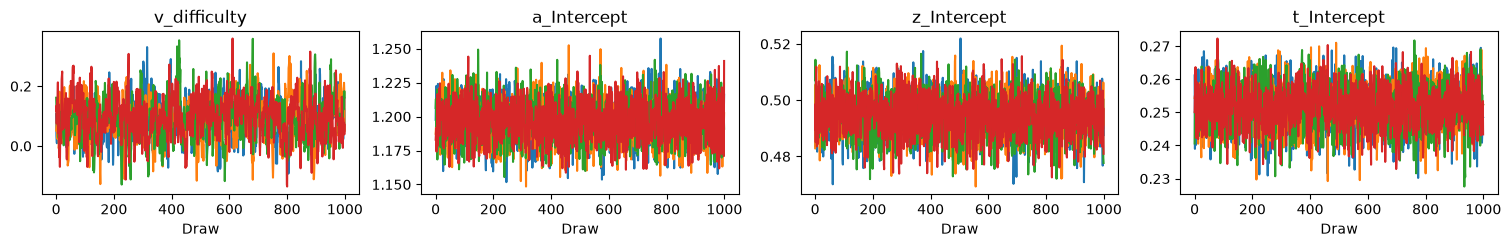

In [12]:
az.plot_trace(idata_A, var_names=["~offset", "~participant_id"], filter_vars="regex")
plt.tight_layout()

### Step 4: Posterior predictive check

We sample many parameter sets from the posterior, forward-simulate `rt`/`response` data from each, and compare to what we observed. If the predicted distribution overlaps the observed one, the model is doing its job. If they diverge, the model is missing something.

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


(-7.0, 7.0)

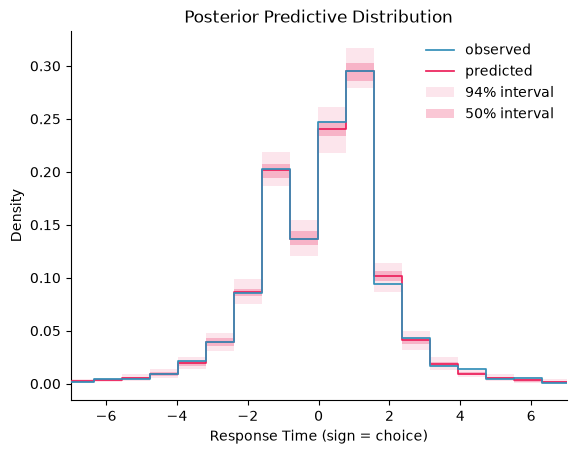

In [13]:
ax = hssm.plotting.plot_predictive(model_A, col_wrap=5)
ax.set_xlim(-7, 7)

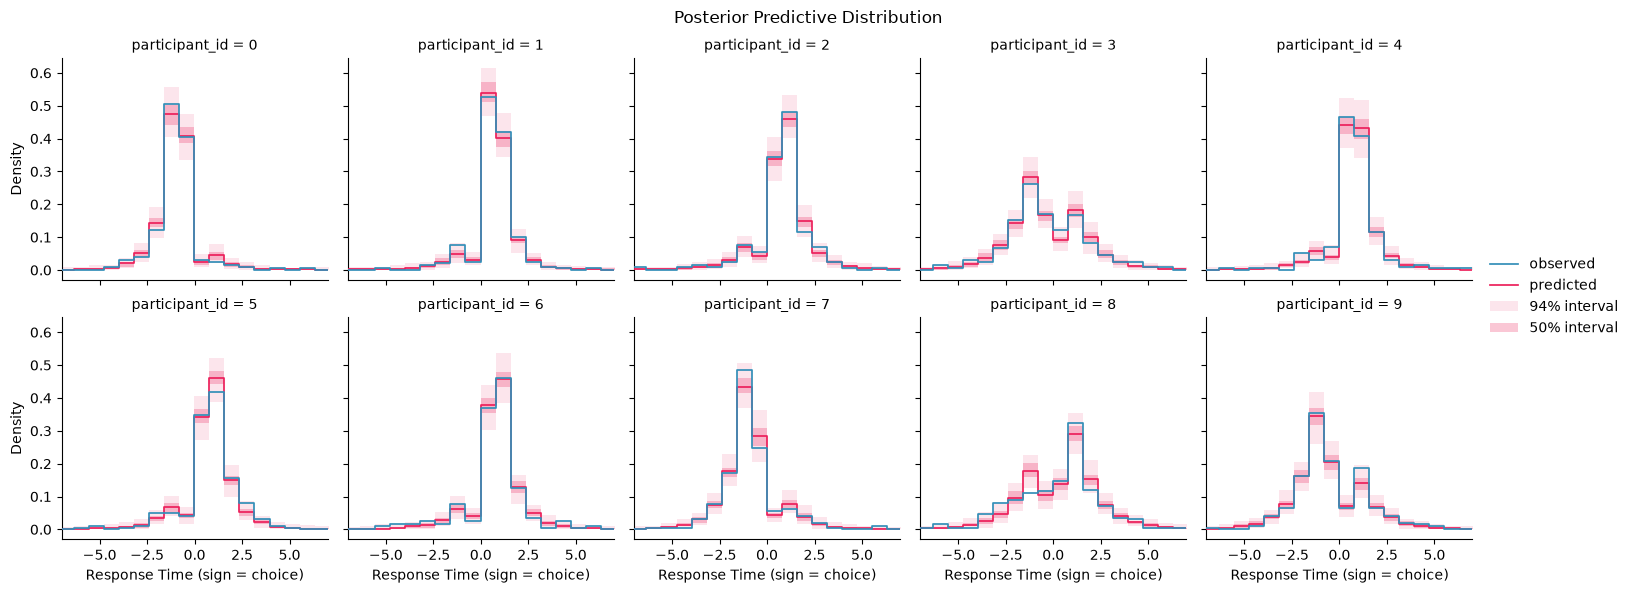

In [14]:
g = hssm.plotting.plot_predictive(model_A, col="participant_id", col_wrap=5)
g.set(xlim=(-7, 7))

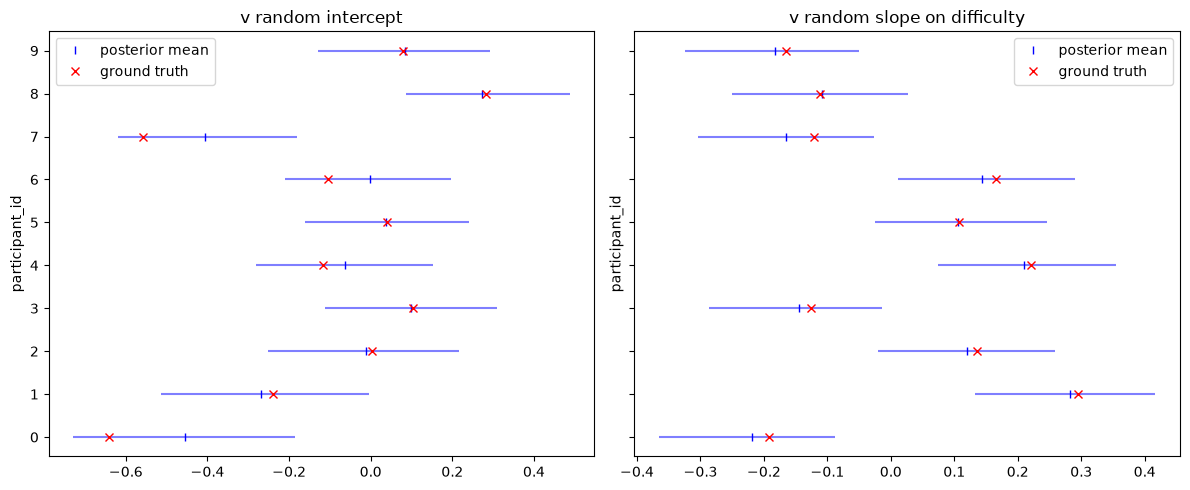

In [15]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_difficulty|participant_id", v_slope_p, "v random slope on difficulty"),
    ],
):
    post = idata_A.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, prob=0.95).values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()

Text(0.5, 0.98, '')

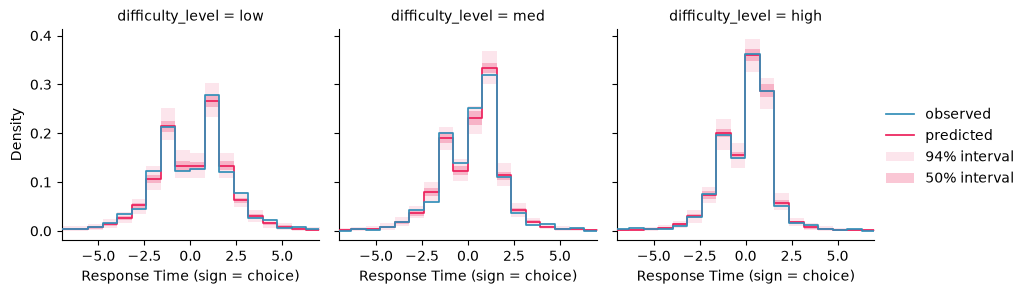

In [16]:
# Posterior predictive: split by difficulty level
g = hssm.plotting.plot_predictive(model_A, col="difficulty_level", col_wrap=3)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

## Variant B: between and within

Same within-subject difficulty effect as in Variant A, but now we also let `age` (a between-subject covariate) affect drift rate.

The `a`, `z`, `t` parameters remain global scalars.

### Step 1: Simulate the data

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


<environment>/src/hssm/base.py:390: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [rt,response]


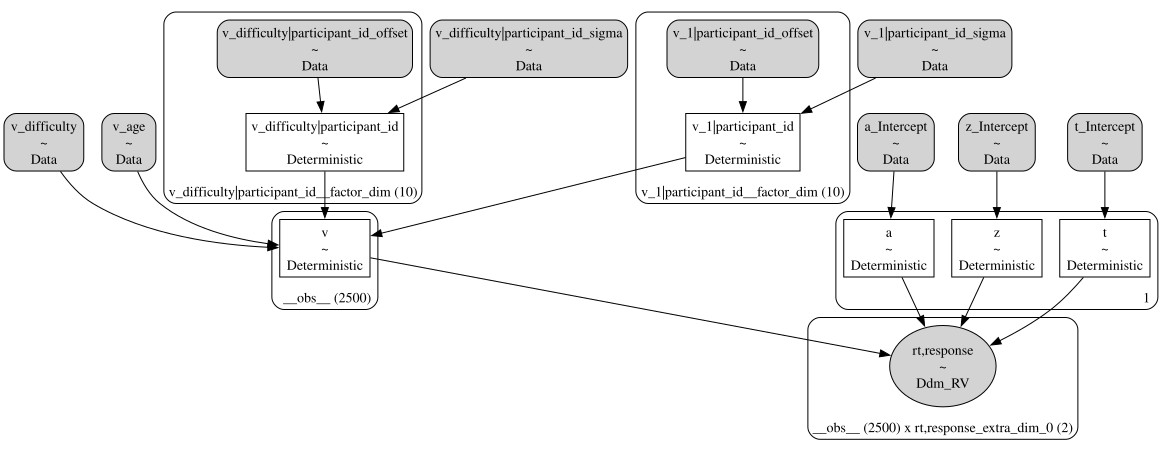

In [17]:
# true coefficients for variant B
beta_v_difficulty = 0.08
beta_v_age = 0.005

v_int_p = rng.normal(0, sigma_v_int, n_participants)
v_slope_p = rng.normal(0, sigma_v_slope, n_participants)

v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_B_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": "v ~ 0 + age + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
)

# Use do-operator: intervene on regression coefficients and random effects
synth_idata_B, synth_model_B = model_B_gen.sample_do(
    params={
        "v_age": beta_v_age,
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_mu": 0.0,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "v_difficulty|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    var_names=["rt,response"],
    return_model=True,
)

pm.model_to_graphviz(synth_model_B, var_names=["rt,response"])

In [18]:
synth_df_B = hssm.utils.predictive_dt_to_dataframe(
    synth_idata_B, predictive_group="prior_predictive"
)

data_B = covariates.copy()
data_B["rt"] = synth_df_B["rt"].values
data_B["response"] = synth_df_B["response"].values
data_B.to_csv(SIM_DIR / "sim_variant_B.csv", index=False)

### Step 2: Fit a fresh HSSM model

In [19]:
data_B = pd.read_csv(SIM_DIR / "sim_variant_B.csv")

# Bin difficulty (3 levels) and age (3 levels) for faceted PPC plots
data_B["difficulty_level"] = pd.qcut(
    data_B["difficulty"], q=3, labels=["low", "med", "high"]
)
data_B["age_level"] = pd.qcut(data_B["age"], q=3, labels=["young", "middle", "older"])

model_B = hssm.HSSM(
    data=data_B,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": "v ~ 0 + age + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2500

Parameters:

v:
    Formula: v ~ 0 + age + difficulty + (1 + difficulty | participant_id)
    Priors:
        v_age ~ Normal(mu: 0.0, sigma: 0.25)
        v_difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: Normal(mu: 2.0, sigma: 3.0), sigma: HalfNormal(sigma: 2.0))
        v_difficulty|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Intercept ~ Gamma(mu: 0.2, sigma: 0.2)
    Link: identity
    Explicit bounds: (0.0, inf)


Lapse probability: 0

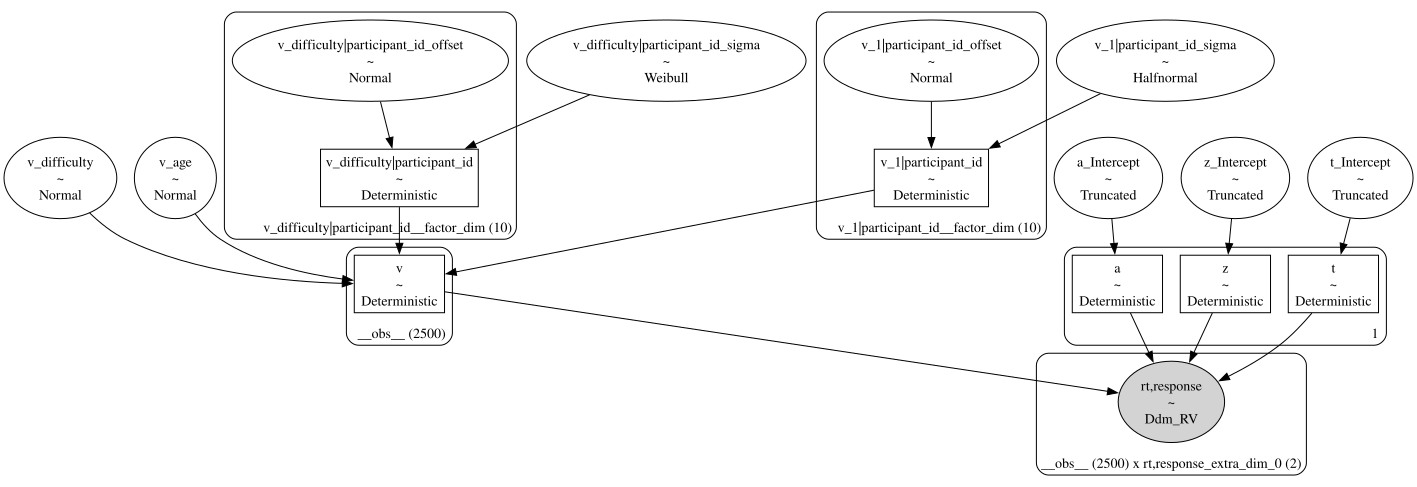

In [20]:
print(model_B)
pm.model_to_graphviz(model_B.pymc_model, var_names=["rt,response"])

In [21]:
idata_B = model_B.sample(**sample_kwargs)

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v_age, v_difficulty, v_1|participant_id_mu, v_1|participant_id_sigma, v_1|participant_id_offset, v_difficulty|participant_id_sigma, v_difficulty|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 217 seconds.


### Step 3: Inspect what got estimated

In [22]:
az.summary(idata_B)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_1|participant_id_sigma,0.486,0.15,0.3,0.77,1143,1272,1.01,0.0043,0.0053
v_difficulty|participant_id[0],-0.092,0.076,-0.21,0.031,882,1312,1.00,0.0026,0.0021
v_difficulty|participant_id[1],0.17,0.077,0.052,0.3,885,1364,1.00,0.0026,0.0021
v_difficulty|participant_id[2],0.102,0.078,-0.017,0.23,889,1390,1.00,0.0026,0.0021
v_difficulty|participant_id[3],0.062,0.076,-0.055,0.19,917,1319,1.00,0.0025,0.002
v_difficulty|participant_id[4],-0.156,0.076,-0.27,-0.033,878,1279,1.00,0.0026,0.0021
v_difficulty|participant_id[5],-0.415,0.079,-0.54,-0.29,881,1319,1.00,0.0026,0.0021
v_difficulty|participant_id[6],-0.125,0.077,-0.25,-0.0011,904,1184,1.00,0.0025,0.0021
v_difficulty|participant_id[7],-0.061,0.077,-0.18,0.062,839,1258,1.00,0.0026,0.0022
v_difficulty|participant_id[8],0.367,0.079,0.25,0.49,916,1321,1.00,0.0026,0.0021


In [23]:
az.summary(idata_B, var_names=["~offset", "~participant_id"], filter_vars="regex")

<environment>/site-packages/arviz_base/utils.py:149: UserWarning: Items starting with ~: ['offset'] have not been found and will be ignored
  warnings.warn(


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_difficulty,0.055,0.074,-0.065,0.17,848,1216,1.00,0.0025,0.0021
v_age,0.0008,0.0037,-0.0049,0.0066,1111,1418,1.00,0.00011,0.0001
a_Intercept,1.2024,0.0147,1.2,1.2,3113,2866,1.00,0.00026,0.00018
z_Intercept,0.4934,0.0073,0.48,0.5,3968,3123,1.00,0.00012,8.1e-05
t_Intercept,0.2569,0.0066,0.25,0.27,3051,2693,1.00,0.00012,8.3e-05


<environment>/site-packages/arviz_base/utils.py:149: UserWarning: Items starting with ~: ['offset'] have not been found and will be ignored
  warnings.warn(


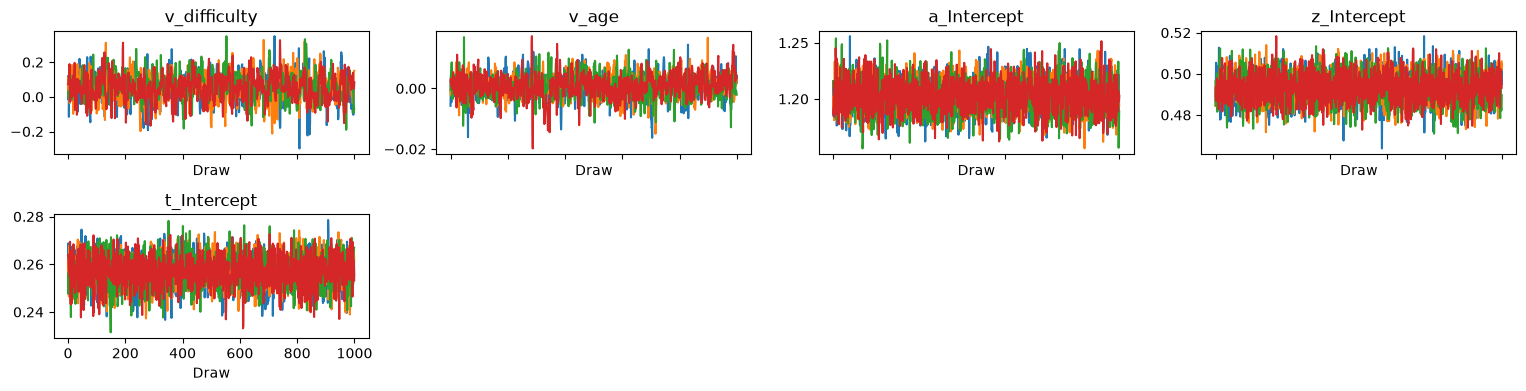

In [24]:
az.plot_trace(idata_B, var_names=["~offset", "~participant_id"], filter_vars="regex")
plt.tight_layout()

### Step 4: Posterior predictive check

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


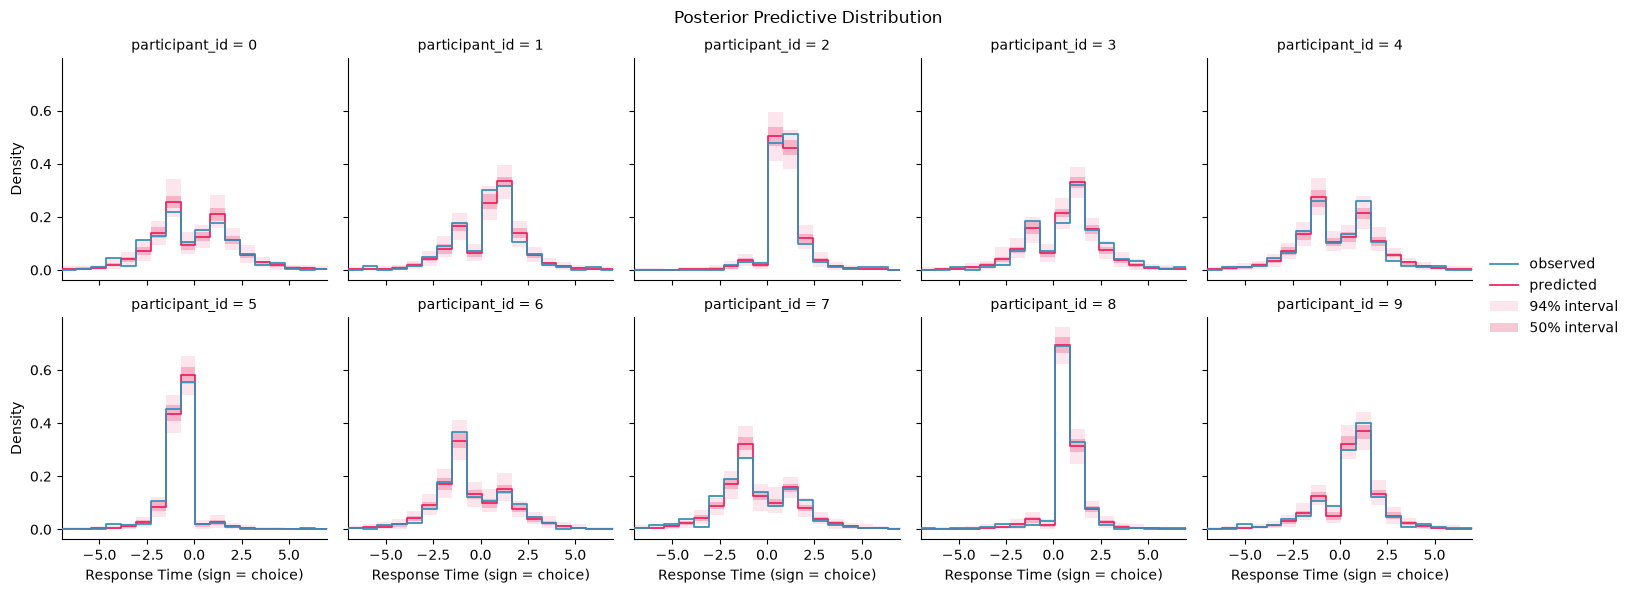

In [25]:
g = hssm.plotting.plot_predictive(model_B, col="participant_id", col_wrap=5)
g.set(xlim=(-7, 7))

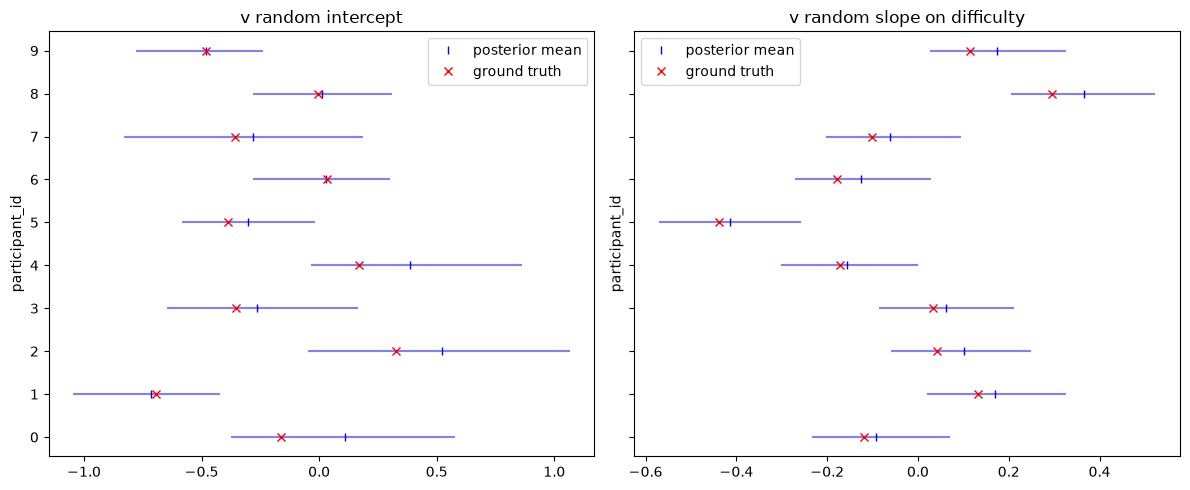

In [26]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_difficulty|participant_id", v_slope_p, "v random slope on difficulty"),
    ],
):
    post = idata_B.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, prob=0.95).values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()

Text(0.5, 0.98, '')

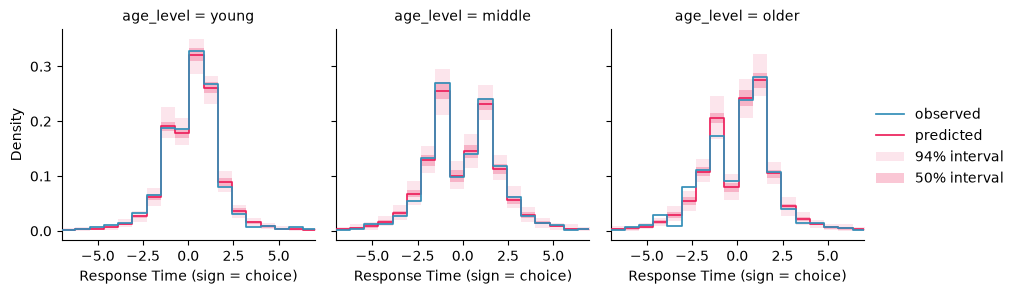

In [27]:
# Posterior predictive: split by age level (between-subject factor)
g = hssm.plotting.plot_predictive(model_B, col="age_level", col_wrap=3)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

Text(0.5, 0.98, '')

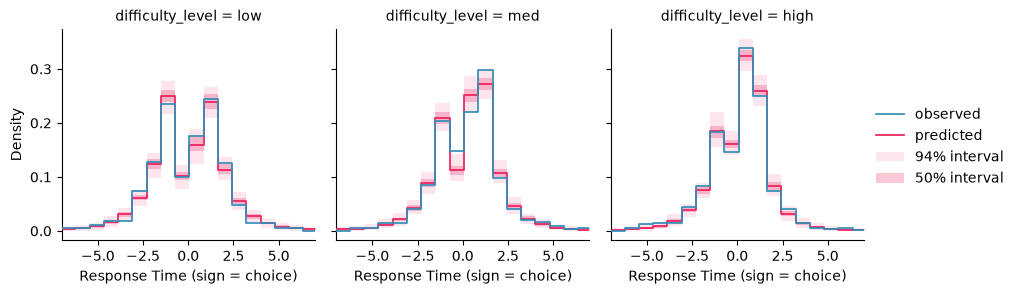

In [28]:
# Posterior predictive: split by difficulty level (within-subject factor)
g = hssm.plotting.plot_predictive(model_B, col="difficulty_level", col_wrap=3)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

## Variant C: interaction 

What if older and younger participants don't just differ in their baseline drift rate, but also in *how much* difficulty affects them? That's an **interaction** between `age` and `difficulty`.

To capture this, we add an `age:difficulty` term to the v regression. Same setup as Variant B otherwise.

### Step 1: Simulate the data

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


<environment>/src/hssm/base.py:390: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()
<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [rt,response]


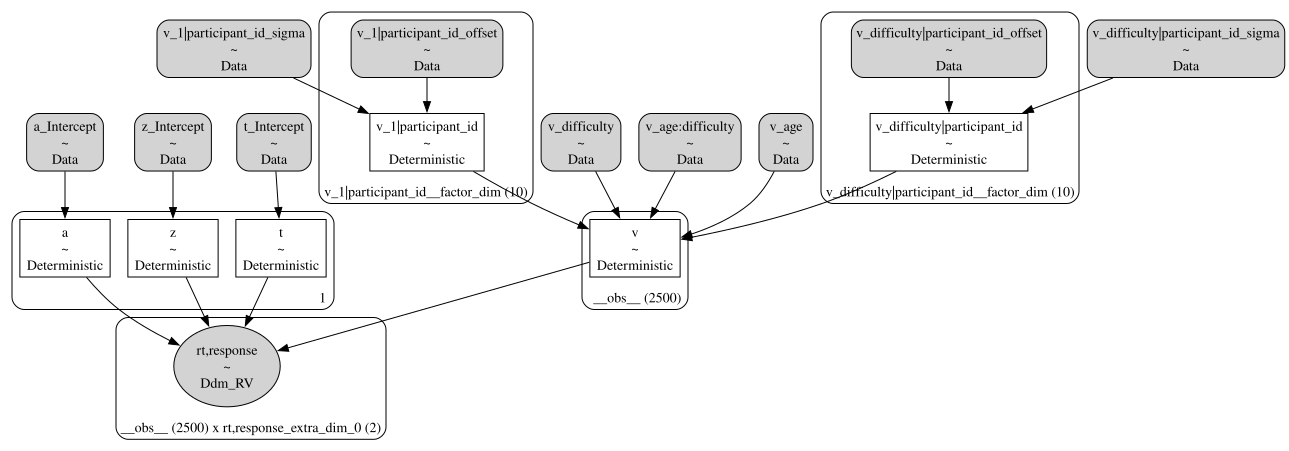

In [29]:
# true coefficients for variant C
beta_v_difficulty = 0.08
beta_v_age = 0.005
beta_v_age_difficulty = 0.0005

v_int_p = rng.normal(0, sigma_v_int, n_participants)
v_slope_p = rng.normal(0, sigma_v_slope, n_participants)

v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope

# Build HSSM model with the regression formula
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_C_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": (
                "v ~ 0 + age + difficulty + age:difficulty + "
                "(1 + difficulty | participant_id)"
            ),
        }
    ],
    noncentered=True,
)

# Use do-operator: intervene on regression coefficients and random effects
synth_idata_C, synth_model_C = model_C_gen.sample_do(
    params={
        "v_age": beta_v_age,
        "v_difficulty": beta_v_difficulty,
        "v_age:difficulty": beta_v_age_difficulty,
        "v_1|participant_id_mu": 0.0,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "v_difficulty|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "z_Intercept": z_true,
        "t_Intercept": t_true,
    },
    draws=1,
    var_names=["rt,response"],
    return_model=True,
)

pm.model_to_graphviz(synth_model_C, var_names=["rt,response"])

In [30]:
synth_df_C = hssm.utils.predictive_dt_to_dataframe(
    synth_idata_C, predictive_group="prior_predictive"
)

data_C = covariates.copy()
data_C["rt"] = synth_df_C["rt"].values
data_C["response"] = synth_df_C["response"].values
data_C.to_csv(SIM_DIR / "sim_variant_C.csv", index=False)

### Step 2: Fit a fresh HSSM model

In [31]:
data_C = pd.read_csv(SIM_DIR / "sim_variant_C.csv")

# Bin difficulty (3 levels) and age (3 levels) for faceted PPC plots
data_C["difficulty_level"] = pd.qcut(
    data_C["difficulty"], q=3, labels=["low", "med", "high"]
)
data_C["age_level"] = pd.qcut(data_C["age"], q=3, labels=["young", "middle", "older"])

model_C = hssm.HSSM(
    data=data_C,
    model="ddm",
    global_formula="y ~ 1",
    include=[
        {
            "name": "v",
            "formula": (
                "v ~ 0 + age + difficulty + age:difficulty + "
                "(1 + difficulty | participant_id)"
            ),
        }
    ],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2500

Parameters:

v:
    Formula: v ~ 0 + age + difficulty + age:difficulty + (1 + difficulty | participant_id)
    Priors:
        v_age ~ Normal(mu: 0.0, sigma: 0.25)
        v_difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_age:difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: Normal(mu: 2.0, sigma: 3.0), sigma: HalfNormal(sigma: 2.0))
        v_difficulty|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
    Link: identity
    Explicit bounds: (0.0, 1.0)

t:
    Formula: t ~ 1
    Priors:
        t_Intercept ~ Gamma(mu: 0.2, sigma: 0.2)


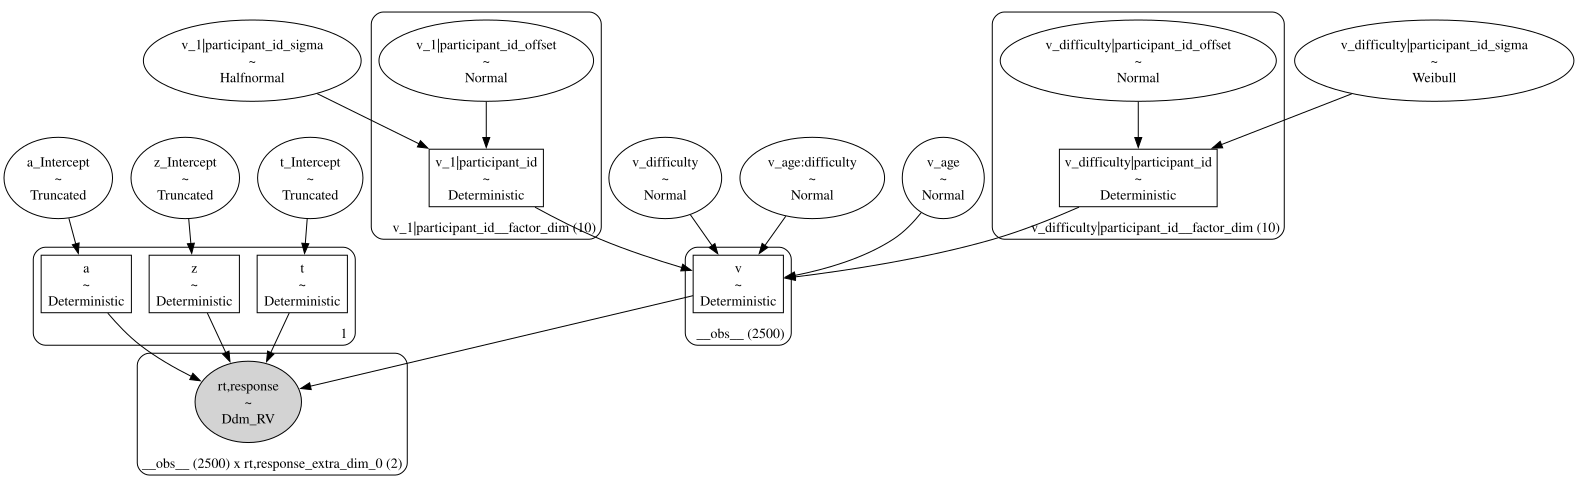

In [32]:
print(model_C)
pm.model_to_graphviz(model_C.pymc_model, var_names=["rt,response"])

In [33]:
idata_C = model_C.sample(**sample_kwargs)

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v_age, v_difficulty, v_age:difficulty, v_1|participant_id_mu, v_1|participant_id_sigma, v_1|participant_id_offset, v_difficulty|participant_id_sigma, v_difficulty|participant_id_offset, a_Intercept, z_Intercept, t_Intercept]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 403 seconds.


### Step 3: Inspect what got estimated

In [34]:
az.summary(idata_C)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_1|participant_id_sigma,0.293,0.099,0.17,0.47,1345,2179,1.00,0.0027,0.0035
v_difficulty|participant_id[0],-0.079,0.088,-0.21,0.058,999,1247,1.00,0.0028,0.0023
v_difficulty|participant_id[1],-0.174,0.072,-0.29,-0.063,1393,1737,1.00,0.0019,0.0015
v_difficulty|participant_id[2],0.265,0.115,0.083,0.45,987,1387,1.00,0.0037,0.0031
v_difficulty|participant_id[3],-0.21,0.069,-0.32,-0.1,1214,1573,1.00,0.002,0.0016
v_difficulty|participant_id[4],-0.113,0.078,-0.24,0.0091,1030,1358,1.00,0.0024,0.002
v_difficulty|participant_id[5],0.181,0.081,0.048,0.31,1307,1436,1.00,0.0023,0.0017
v_difficulty|participant_id[6],-0.116,0.071,-0.23,-0.0064,1375,1673,1.00,0.0019,0.0015
v_difficulty|participant_id[7],0.044,0.099,-0.11,0.2,991,1418,1.00,0.0031,0.0026
v_difficulty|participant_id[8],0.077,0.077,-0.048,0.2,1335,1671,1.00,0.0021,0.0016


In [35]:
az.summary(idata_C, var_names=["~offset", "~participant_id"], filter_vars="regex")

<environment>/site-packages/arviz_base/utils.py:149: UserWarning: Items starting with ~: ['offset'] have not been found and will be ignored
  warnings.warn(


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_difficulty,-0.061,0.129,-0.26,0.15,1167,1438,1.00,0.0038,0.003
v_age:difficulty,0.0018,0.0029,-0.0029,0.0065,986,1296,1.00,9.4e-05,7.9e-05
v_age,0.0036,0.0023,5.5e-05,0.0071,1648,2151,1.00,5.5e-05,5.2e-05
a_Intercept,1.1973,0.0135,1.2,1.2,3600,2786,1.00,0.00022,0.00017
z_Intercept,0.5094,0.0073,0.5,0.52,4459,3119,1.00,0.00011,7.8e-05
t_Intercept,0.2518,0.0069,0.24,0.26,3621,2878,1.00,0.00011,8.2e-05


<environment>/site-packages/arviz_base/utils.py:149: UserWarning: Items starting with ~: ['offset'] have not been found and will be ignored
  warnings.warn(


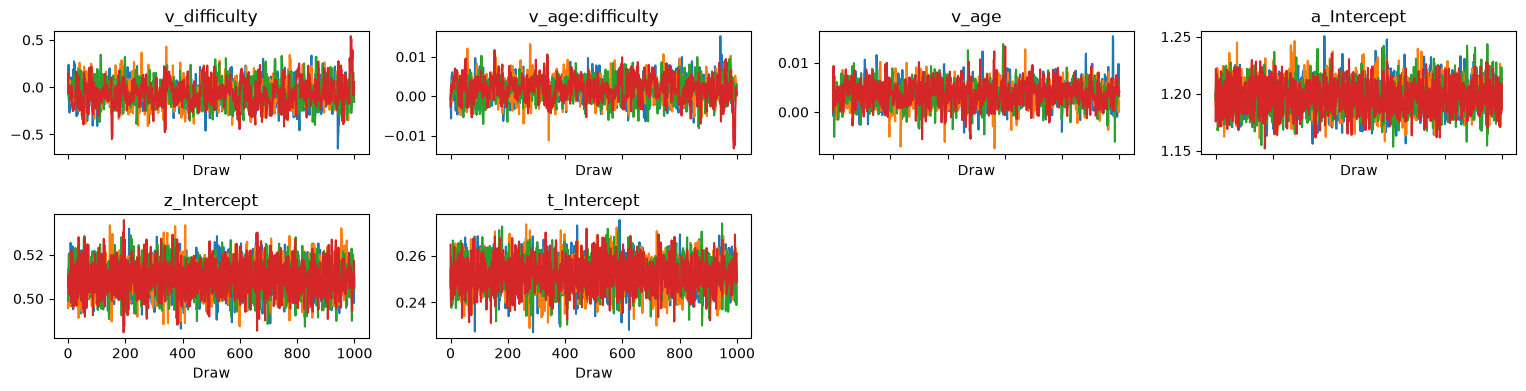

In [36]:
az.plot_trace(idata_C, var_names=["~offset", "~participant_id"], filter_vars="regex")
plt.tight_layout()

### Step 4: Posterior predictive check

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


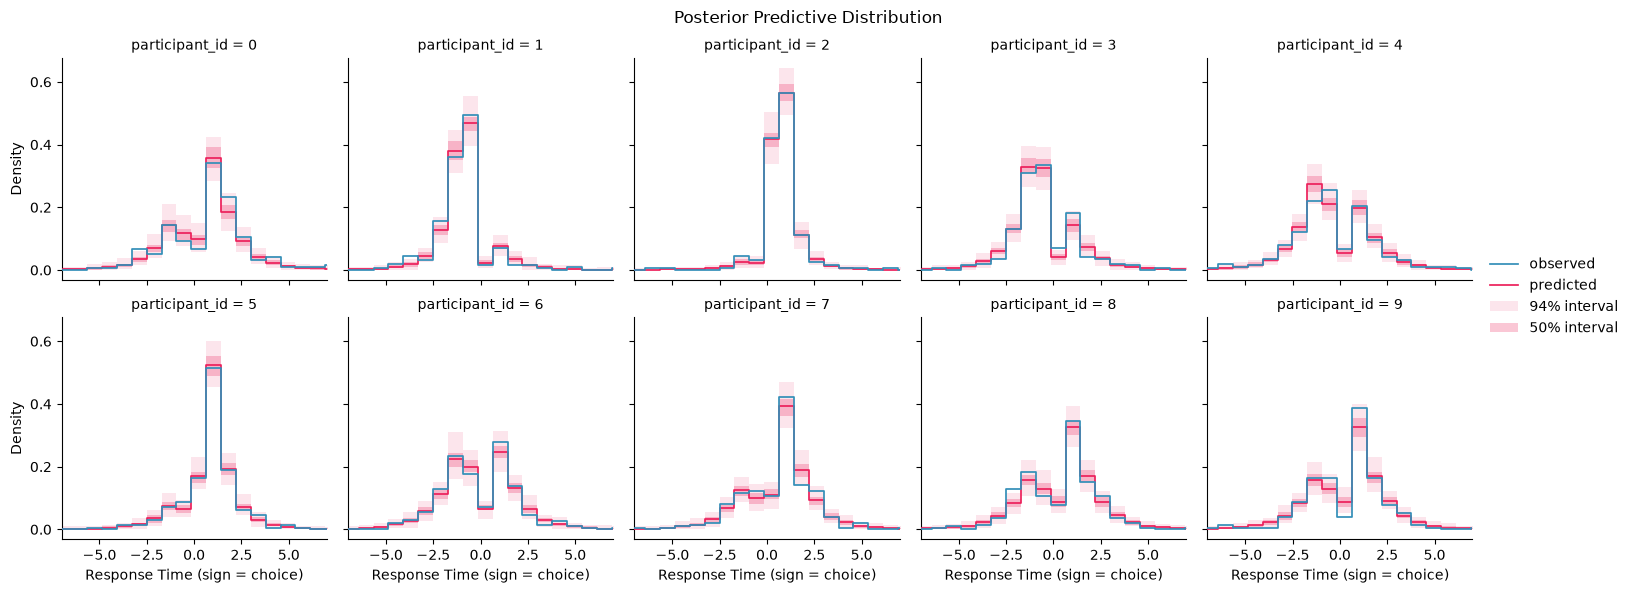

In [37]:
g = hssm.plotting.plot_predictive(model_C, col="participant_id", col_wrap=5)
g.set(xlim=(-7, 7))

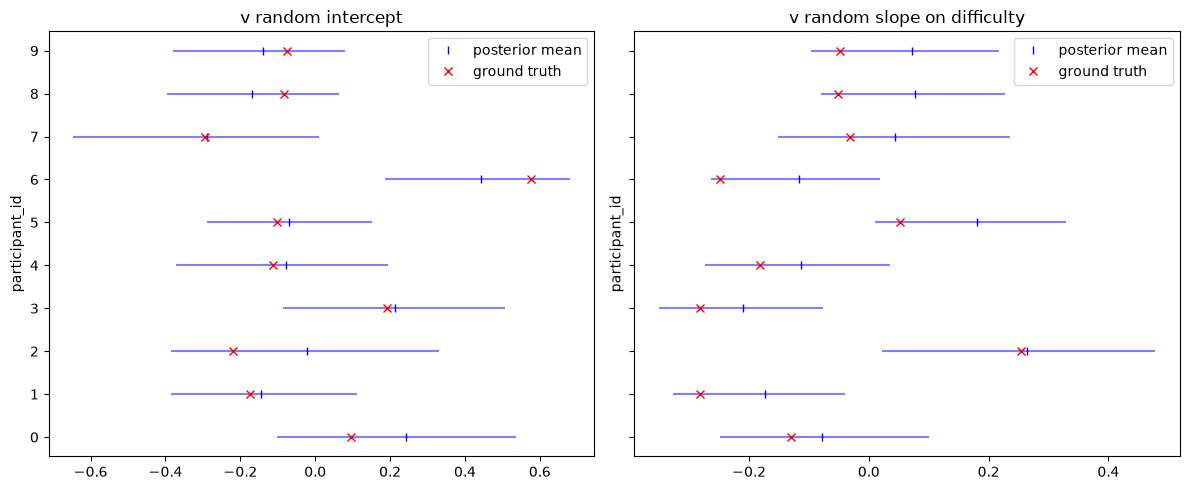

In [38]:
# Participant-wise parameter recovery for v (random intercepts and slopes)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v random intercept"),
        ("v_difficulty|participant_id", v_slope_p, "v random slope on difficulty"),
    ],
):
    post = idata_C.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, prob=0.95).values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    ax.set_ylabel("participant_id")
    ax.legend()

plt.tight_layout()

Text(0.5, 0.98, '')

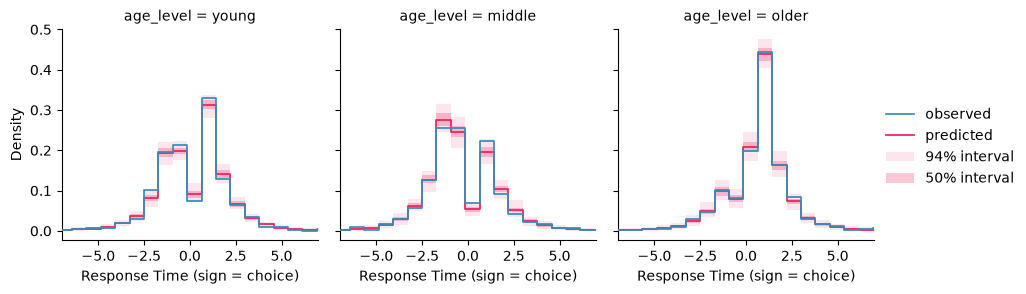

In [39]:
# Posterior predictive: faceted by age level (between-subject factor)
g = hssm.plotting.plot_predictive(model_C, col="age_level", col_wrap=3)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

Text(0.5, 0.98, '')

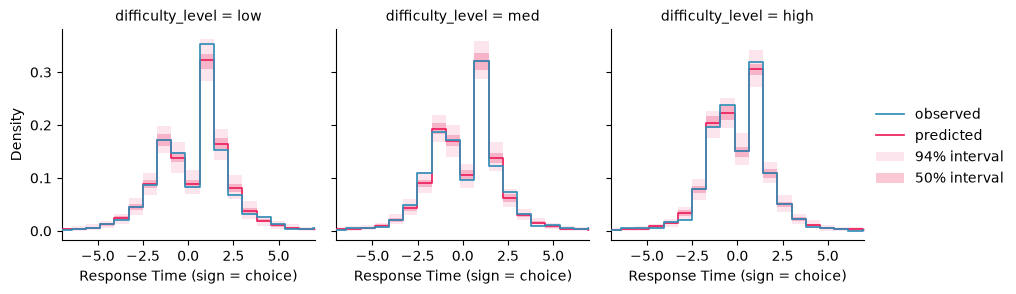

In [40]:
# Posterior predictive: faceted by difficulty level (within-subject factor)
g = hssm.plotting.plot_predictive(model_C, col="difficulty_level", col_wrap=3)
g.set(xlim=(-7, 7))
g.fig.suptitle("")

Text(0.5, 0.98, '')

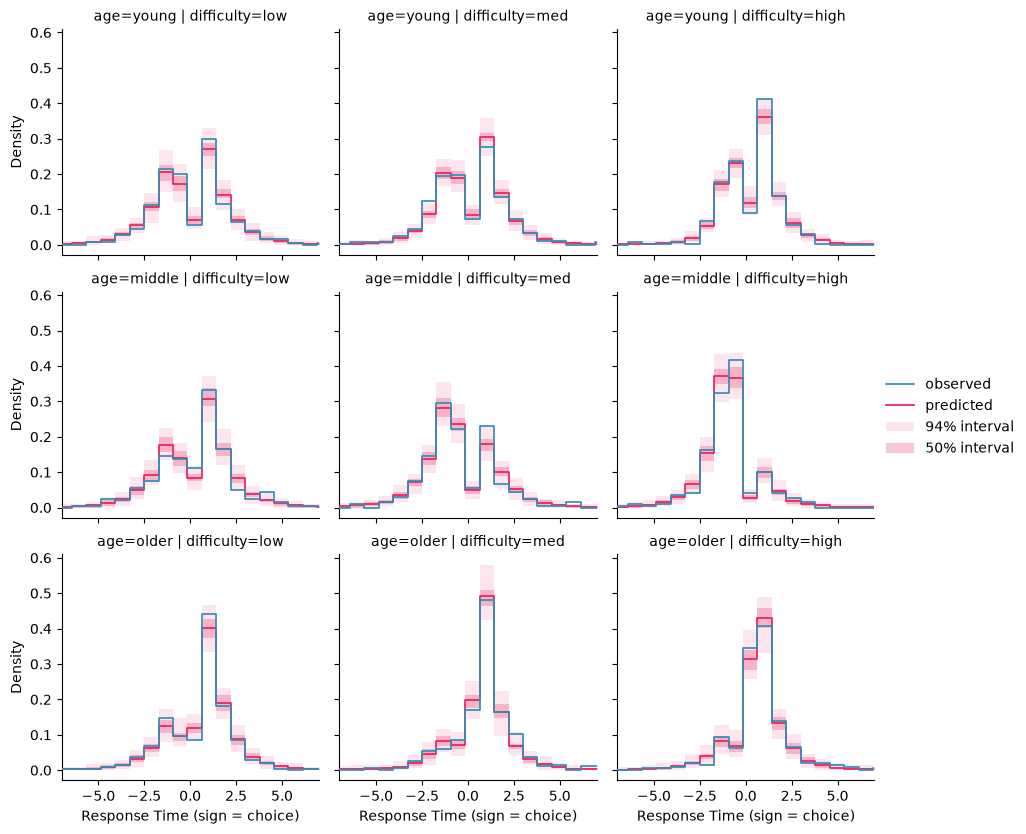

In [41]:
# Posterior predictive: 3x3 interaction grid (age x difficulty)
g = hssm.plotting.plot_predictive(model_C, row="age_level", col="difficulty_level")
g.set(xlim=(-7, 7))
g.set_titles(template="age={row_name} | difficulty={col_name}")
g.fig.suptitle("")

## Variant D: full hierarchy on every parameter

In Variants A–C we kept `a`, `z`, `t` as global scalars to keep the spotlight on the v regression. In real experiments, however, every DDM parameter usually shows individual differences — some people have higher boundary separations, some have longer non-decision times, etc.

Variant D shows what the **fully hierarchical** case looks like: same v regression as Variant A, but now `global_formula="y ~ 1 + (1 | participant_id)"` adds participant-level random intercepts to **a, z, t** as well. The simulator generates per-participant values for these to match.

This is the most realistic specification for real data, but it's also slower to fit (more parameters to sample).

### Step 1: Simulate the data

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


<environment>/src/hssm/base.py:390: UserWarning: You set choices to be (-1, 1), but [-1] are missing from your dataset.
  self._post_check_data_sanity()


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [rt,response]


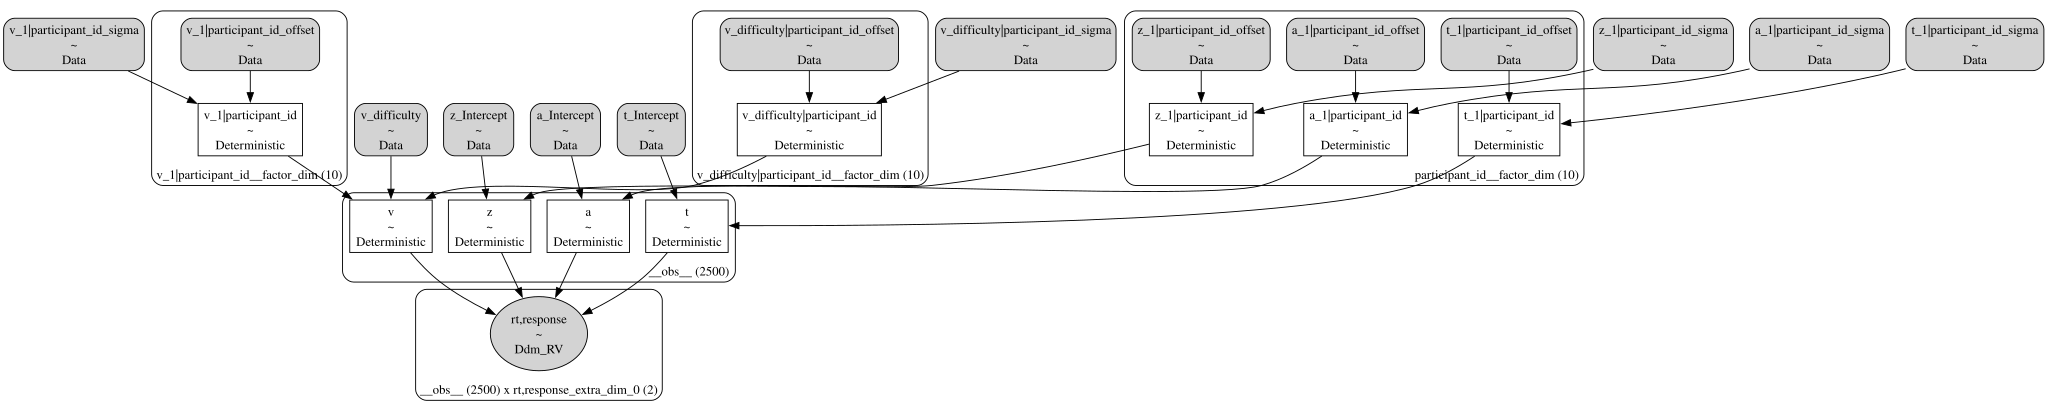

In [42]:
# Variant D: simulate with per-participant a, z, t
beta_v_difficulty = 0.08

v_int_p = rng.normal(0, sigma_v_int, n_participants)
v_slope_p = rng.normal(0, sigma_v_slope, n_participants)

# Per-participant a, z, t (centered on the scalar means used in A/B/C)
sigma_a, sigma_z, sigma_t = 0.15, 0.05, 0.05
a_p = a_true + rng.normal(0, sigma_a, n_participants)
z_p = np.clip(z_true + rng.normal(0, sigma_z, n_participants), 0.05, 0.95)
t_p = np.clip(t_true + rng.normal(0, sigma_t, n_participants), 0.001, None)

# Noncentered offsets, derived from the (possibly clipped) per-participant values
v_int_offset = v_int_p / sigma_v_int
v_slope_offset = v_slope_p / sigma_v_slope
a_int_offset = (a_p - a_true) / sigma_a
z_int_offset = (z_p - z_true) / sigma_z
t_int_offset = (t_p - t_true) / sigma_t

# Build HSSM model with full hierarchy
dummy_data = covariates.copy()
dummy_data["rt"] = 1.0
dummy_data["response"] = 1.0

model_D_gen = hssm.HSSM(
    data=dummy_data,
    model="ddm",
    global_formula="y ~ 1 + (1 | participant_id)",
    include=[
        {
            "name": "v",
            "formula": "v ~ 0 + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
)

# Use do-operator: intervene on every regression coefficient and random effect
synth_idata_D, synth_model_D = model_D_gen.sample_do(
    params={
        "v_difficulty": beta_v_difficulty,
        "v_1|participant_id_mu": 0.0,
        "v_1|participant_id_sigma": sigma_v_int,
        "v_1|participant_id_offset": v_int_offset,
        "v_difficulty|participant_id_sigma": sigma_v_slope,
        "v_difficulty|participant_id_offset": v_slope_offset,
        "a_Intercept": a_true,
        "a_1|participant_id_sigma": sigma_a,
        "a_1|participant_id_offset": a_int_offset,
        "z_Intercept": z_true,
        "z_1|participant_id_sigma": sigma_z,
        "z_1|participant_id_offset": z_int_offset,
        "t_Intercept": t_true,
        "t_1|participant_id_sigma": sigma_t,
        "t_1|participant_id_offset": t_int_offset,
    },
    draws=1,
    var_names=["rt,response"],
    return_model=True,
)

pm.model_to_graphviz(synth_model_D, var_names=["rt,response"])

In [43]:
synth_df_D = hssm.utils.predictive_dt_to_dataframe(
    synth_idata_D, predictive_group="prior_predictive"
)

data_D = covariates.copy()
data_D["rt"] = synth_df_D["rt"].values
data_D["response"] = synth_df_D["response"].values
data_D.to_csv(SIM_DIR / "sim_variant_D.csv", index=False)
data_D.head()

,participant_id,difficulty,age,rt,response
0,0,6.369617,60.357299,2.402679,-1.0
1,0,2.697867,60.357299,1.814786,-1.0
2,0,0.409735,60.357299,2.147971,-1.0
3,0,0.165276,60.357299,0.750644,-1.0
4,0,8.132702,60.357299,0.470155,1.0


### Step 2: Fit a fresh HSSM model

In [44]:
data_D = pd.read_csv(SIM_DIR / "sim_variant_D.csv")

model_D = hssm.HSSM(
    data=data_D,
    model="ddm",
    global_formula="y ~ 1 + (1 | participant_id)",
    include=[
        {
            "name": "v",
            "formula": "v ~ 0 + difficulty + (1 + difficulty | participant_id)",
        }
    ],
    noncentered=True,
)

No common intercept. Bounds for parameter v is not applied due to a current limitation of Bambi. This will change in the future.


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 2500

Parameters:

v:
    Formula: v ~ 0 + difficulty + (1 + difficulty | participant_id)
    Priors:
        v_difficulty ~ Normal(mu: 0.0, sigma: 0.25)
        v_1|participant_id ~ Normal(mu: Normal(mu: 2.0, sigma: 3.0), sigma: HalfNormal(sigma: 2.0))
        v_difficulty|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Formula: a ~ 1 + (1 | participant_id)
    Priors:
        a_Intercept ~ Gamma(mu: 1.5, sigma: 0.75)
        a_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (0.0, inf)

z:
    Formula: z ~ 1 + (1 | participant_id)
    Priors:
        z_Intercept ~ Beta(alpha: 10.0, beta: 10.0)
        z_1|participant_id ~ Normal(mu: 0.0, sigma: Weibull(alpha: 1.5, beta: 0.3))
    Link: identity
    Explicit bounds: (0.0,

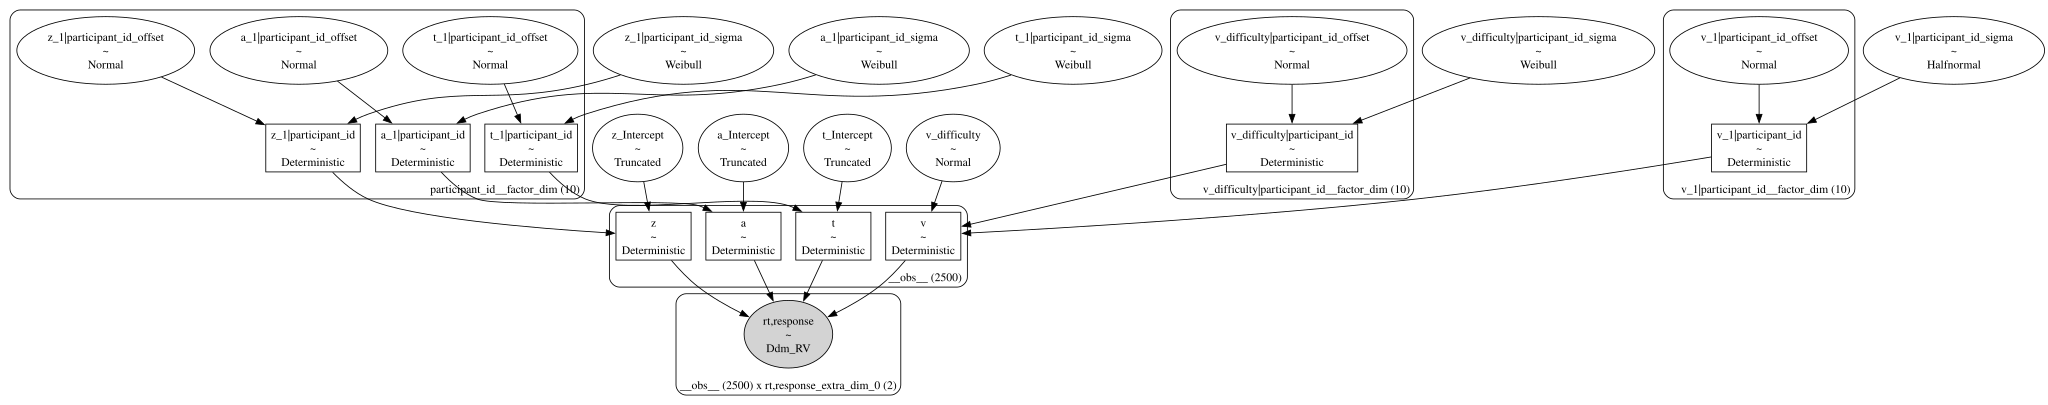

In [45]:
print(model_D)
pm.model_to_graphviz(model_D.pymc_model, var_names=["rt,response"])

In [46]:
idata_D = model_D.sample(**sample_kwargs)

Using default initvals. 



Initializing NUTS using adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v_difficulty, v_1|participant_id_mu, v_1|participant_id_sigma, v_1|participant_id_offset, v_difficulty|participant_id_sigma, v_difficulty|participant_id_offset, a_Intercept, a_1|participant_id_sigma, a_1|participant_id_offset, z_Intercept, z_1|participant_id_sigma, z_1|participant_id_offset, t_Intercept, t_1|participant_id_sigma, t_1|participant_id_offset]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 210 seconds.


### Step 3: Inspect what got estimated

In [47]:
az.summary(idata_D)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_1|participant_id_sigma,0.453,0.14,0.28,0.68,1275,1924,1.00,0.0037,0.0056
v_difficulty|participant_id[0],-0.21,0.062,-0.31,-0.11,1099,1361,1.00,0.0019,0.0015
v_difficulty|participant_id[1],0.071,0.063,-0.026,0.17,1071,1702,1.00,0.0019,0.0015
v_difficulty|participant_id[2],-0.09,0.061,-0.19,0.0071,1011,1364,1.00,0.0019,0.0015
v_difficulty|participant_id[3],0.322,0.067,0.22,0.43,1222,1873,1.00,0.0019,0.0015
v_difficulty|participant_id[4],0.115,0.067,0.0087,0.22,1144,1657,1.00,0.002,0.0015
v_difficulty|participant_id[5],-0.089,0.063,-0.19,0.011,1081,1417,1.00,0.0019,0.0015
v_difficulty|participant_id[6],-0.081,0.061,-0.18,0.016,1000,1616,1.00,0.0019,0.0016
v_difficulty|participant_id[7],-0.069,0.063,-0.17,0.032,987,1461,1.00,0.002,0.0016
v_difficulty|participant_id[8],0.169,0.064,0.071,0.28,1126,1731,1.00,0.0019,0.0015


In [48]:
az.summary(idata_D, var_names=["~offset", "~participant_id"], filter_vars="regex")

<environment>/site-packages/arviz_base/utils.py:149: UserWarning: Items starting with ~: ['offset'] have not been found and will be ignored
  warnings.warn(


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v_difficulty,0.107,0.06,0.011,0.2,957,1341,1.00,0.0019,0.0016
a_Intercept,1.185,0.057,1.1,1.3,1441,1705,1.00,0.0015,0.0015
z_Intercept,0.496,0.035,0.44,0.55,1471,1826,1.00,0.0009,0.00078
t_Intercept,0.256,0.0218,0.22,0.29,1621,1950,1.00,0.00054,0.00047


<environment>/site-packages/arviz_base/utils.py:149: UserWarning: Items starting with ~: ['offset'] have not been found and will be ignored
  warnings.warn(


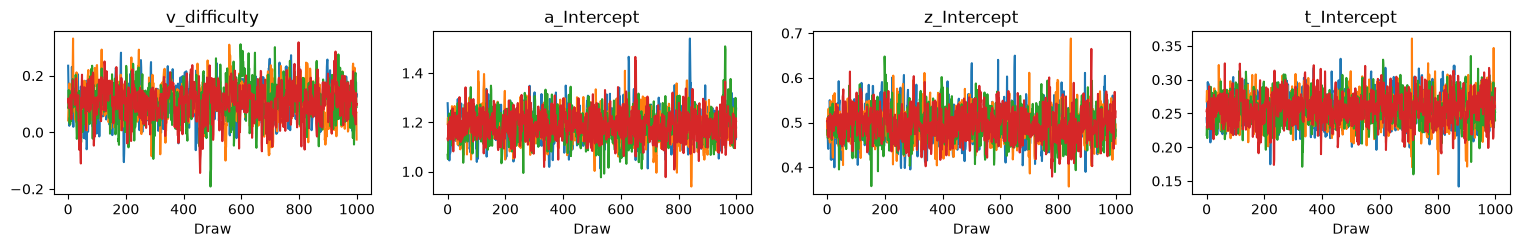

In [49]:
az.plot_trace(idata_D, var_names=["~offset", "~participant_id"], filter_vars="regex")
plt.tight_layout()

### Step 4: Posterior predictive check

No posterior_predictive samples found. Generating posterior_predictive samples using the provided DataTree object and the original data. This will modify the provided DataTree object, or if not provided, the traces object stored inside the model.


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


<environment>/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run ddm_RV_rv{"(),(),(),(),()->(2)"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


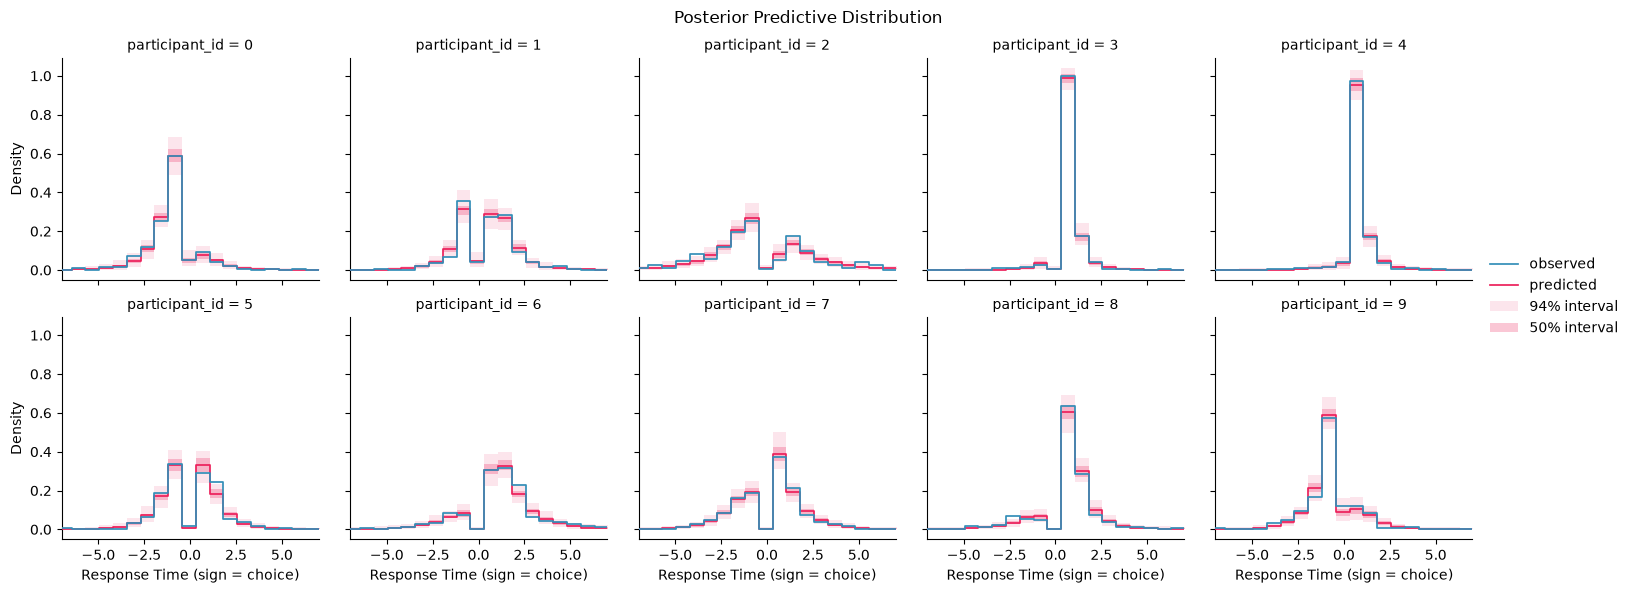

In [50]:
g = hssm.plotting.plot_predictive(model_D, col="participant_id", col_wrap=5)
g.set(xlim=(-7, 7))

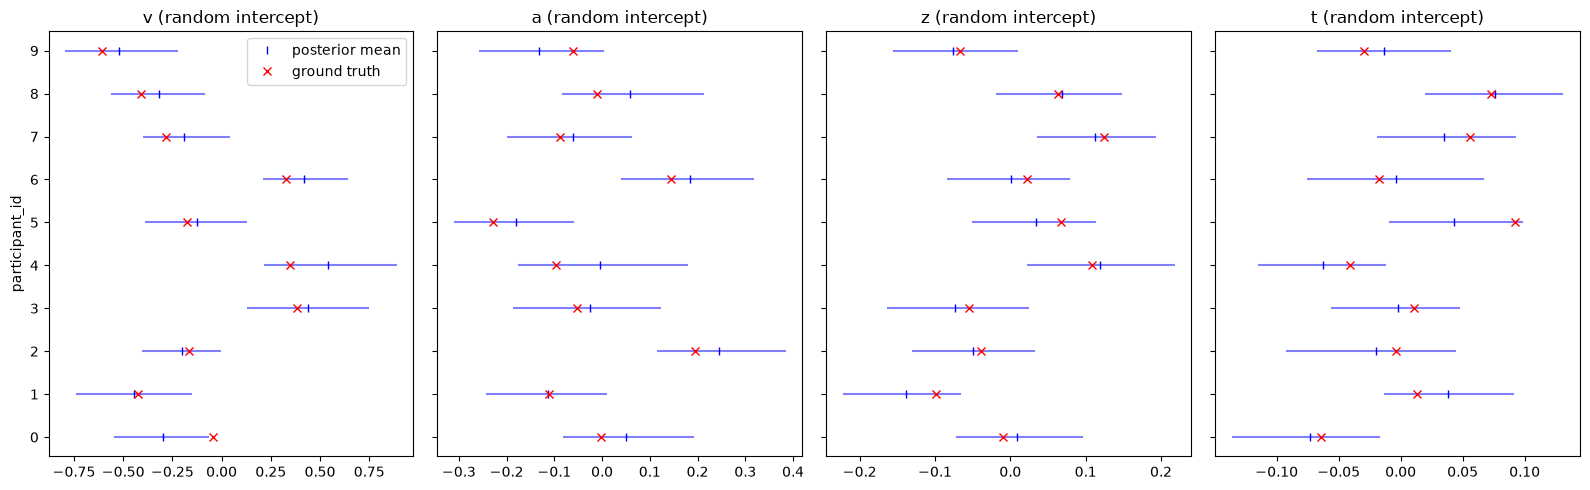

In [51]:
# Participant-wise parameter recovery for all DDM parameters
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(16, 5), sharey=True)

for ax, (param_name, truth, label) in zip(
    axes,
    [
        ("v_1|participant_id", v_int_p, "v (random intercept)"),
        ("a_1|participant_id", a_p - a_true, "a (random intercept)"),
        ("z_1|participant_id", z_p - z_true, "z (random intercept)"),
        ("t_1|participant_id", t_p - t_true, "t (random intercept)"),
    ],
):
    post = idata_D.posterior[param_name]
    mean = post.mean(dim=["chain", "draw"]).values
    hdi = az.hdi(post, prob=0.95).values

    yvals = np.arange(n_participants)
    ax.hlines(yvals, hdi[:, 0], hdi[:, 1], color="blue", alpha=0.5)
    ax.plot(mean, yvals, "|", color="blue", label="posterior mean")
    ax.plot(truth, yvals, "x", color="red", label="ground truth")
    ax.set_title(label)
    ax.set_yticks(yvals)
    if ax is axes[0]:
        ax.set_ylabel("participant_id")
        ax.legend()

plt.tight_layout()